Question 9: 
How are sudden spikes in grocery-price-related indicators associated with changes in Google search interest for inflation and food prices in Germany?

In [28]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
FINANCE_FILE = "yahoo_finance.json"
INFLATION_FILE = "iot_Inflation.json"
FOOD_FILE = "iot_Lebensmittelpreise.json"

In [30]:
def load_yahoo_json(filepath):
    
    with open(filepath, "r", encoding="utf-8") as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data)

    rename_map = {
        "('Date', '')": "date",
        "('Close', 'ZW=F')": "close",
        "('High', 'ZW=F')": "high",
        "('Low', 'ZW=F')": "low",
        "('Open', 'ZW=F')": "open",
        "('Volume', 'ZW=F')": "volume",
        "('price_change', '')": "price_change"
    }

    dataframe = dataframe.rename(columns=rename_map)

    return dataframe


def load_trends_json(filepath):
    
    with open(filepath, "r", encoding="utf-8") as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data["data"])

    return dataframe

In [31]:
finance_raw = load_yahoo_json(FINANCE_FILE)
inflation_raw = load_trends_json(INFLATION_FILE)
food_raw = load_trends_json(FOOD_FILE)

print("Finance raw:", finance_raw.shape)
print("Inflation trends:", inflation_raw.shape)
print("Food trends:", food_raw.shape)

print(finance_raw.columns)

Finance raw: (1258, 8)
Inflation trends: (61, 2)
Food trends: (61, 2)
Index(['('index', '')', 'date', 'close', 'high', 'low', 'open', 'volume',
       'price_change'],
      dtype='str')


In [32]:
def clean_finance_data(df):

    cleaned = df.copy()

    cleaned["date"] = pd.to_datetime(cleaned["date"], errors="coerce")
    cleaned["close"] = pd.to_numeric(cleaned["close"], errors="coerce")
    cleaned["price_change"] = pd.to_numeric(cleaned["price_change"], errors="coerce")

    cleaned = cleaned.dropna(subset=["date", "close"])
    cleaned = cleaned.sort_values("date").reset_index(drop=True)

    return cleaned


def clean_trends_data(df):

    cleaned = df.copy()

    cleaned["date"] = pd.to_datetime(cleaned["date"], errors="coerce")
    cleaned["value"] = pd.to_numeric(cleaned["value"], errors="coerce")

    cleaned = cleaned.dropna(subset=["date", "value"])
    cleaned = cleaned.sort_values("date").reset_index(drop=True)

    return cleaned

In [33]:
finance_clean = clean_finance_data(finance_raw)
inflation_clean = clean_trends_data(inflation_raw)
food_clean = clean_trends_data(food_raw)

print("Finance clean:", finance_clean.shape)
print("Inflation clean:", inflation_clean.shape)
print("Food clean:", food_clean.shape)

finance_clean.head()

Finance clean: (1258, 8)
Inflation clean: (61, 2)
Food clean: (61, 2)


,"('index', '')",date,close,high,low,open,volume,price_change
0,0,2020-01-02,560.25,567.50,558.25,559.50,49931,NaN
1,1,2020-01-03,554.50,562.00,551.75,560.75,44180,-0.010263
2,2,2020-01-06,550.00,555.25,546.75,552.50,47904,-0.008115
3,3,2020-01-07,550.25,551.00,545.50,549.50,41346,0.000455
4,4,2020-01-08,552.75,555.75,545.25,549.50,51322,0.004543


In [34]:
def add_time_features(df):

    result = df.copy()

    result["year"] = result["date"].dt.year
    result["month"] = result["date"].dt.to_period("M").dt.to_timestamp()

    return result

In [35]:
finance_features = add_time_features(finance_clean)
inflation_features = add_time_features(inflation_clean)
food_features = add_time_features(food_clean)

print(finance_features.shape)
print(inflation_features.shape)
print(food_features.shape)

(1258, 10)
(61, 4)
(61, 4)


In [36]:
finance_monthly = (
    finance_features.groupby("month", as_index=False)
    .agg(
        close=("close", "mean"),
        price_change=("price_change", "mean")
    )
    .sort_values("month")
    .reset_index(drop=True)
)

finance_monthly.head()

,month,close,price_change
0,2020-01-01,565.047619,-0.000535
1,2020-02-01,549.210526,-0.002294
2,2020-03-01,535.159091,0.003488
3,2020-04-01,541.309524,-0.003241
4,2020-05-01,515.150000,-0.000780


In [37]:
trends_df = pd.merge(
    inflation_features[["month", "value"]],
    food_features[["month", "value"]],
    on="month",
    how="inner",
    suffixes=("_inflation", "_food")
)

trends_df.head()

,month,value_inflation,value_food
0,2019-12-01,13.00,0.00
1,2020-01-01,15.75,14.75
2,2020-02-01,14.25,24.25
3,2020-03-01,34.80,15.20
4,2020-04-01,28.75,9.00


In [38]:
analysis_df = pd.merge(
    finance_monthly,
    trends_df,
    on="month",
    how="inner"
)

analysis_df = analysis_df.sort_values("month").reset_index(drop=True)

analysis_df.head()

,month,close,price_change,value_inflation,value_food
0,2020-01-01,565.047619,-0.000535,15.75,14.75
1,2020-02-01,549.210526,-0.002294,14.25,24.25
2,2020-03-01,535.159091,0.003488,34.80,15.20
3,2020-04-01,541.309524,-0.003241,28.75,9.00
4,2020-05-01,515.150000,-0.000780,23.00,10.00


In [39]:
spike_threshold = analysis_df["price_change"].quantile(0.90)

analysis_df["price_spike"] = analysis_df["price_change"] >= spike_threshold

print("Spike threshold:", round(spike_threshold, 4))
print("Number of spikes:", analysis_df["price_spike"].sum())

Spike threshold: 0.0047
Number of spikes: 6


In [40]:
correlation_price_inflation = analysis_df[["price_change", "value_inflation"]].corr().iloc[0, 1]
correlation_price_food = analysis_df[["price_change", "value_food"]].corr().iloc[0, 1]

print("Correlation: price_change vs inflation searches =", round(correlation_price_inflation, 3))
print("Correlation: price_change vs food-price searches =", round(correlation_price_food, 3))

Correlation: price_change vs inflation searches = -0.055
Correlation: price_change vs food-price searches = -0.097


In [41]:
sns.set_theme(style="whitegrid")

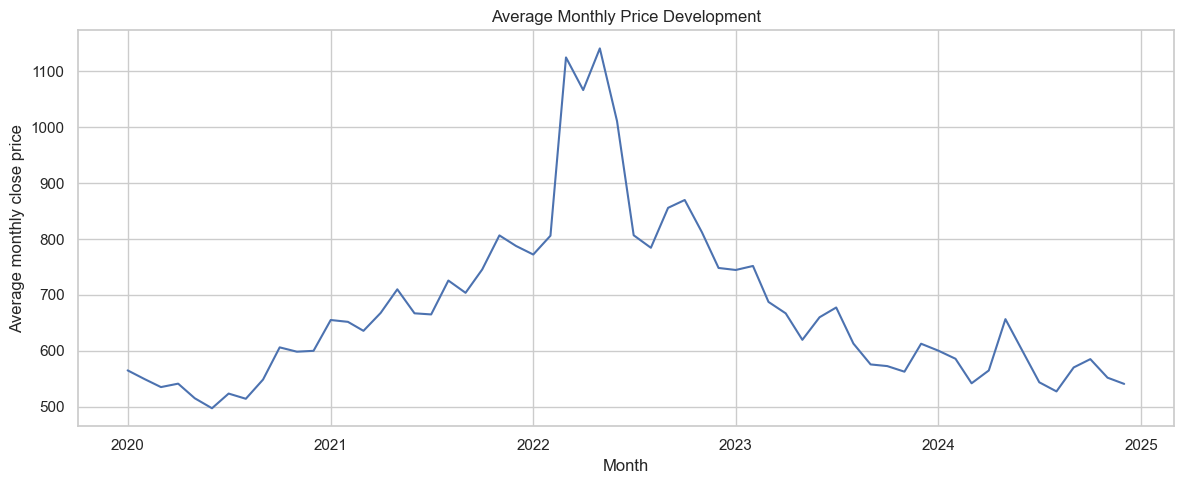

In [42]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=analysis_df, x="month", y="close")

plt.title("Average Monthly Price Development")
plt.xlabel("Month")
plt.ylabel("Average monthly close price")
plt.tight_layout()
plt.show()

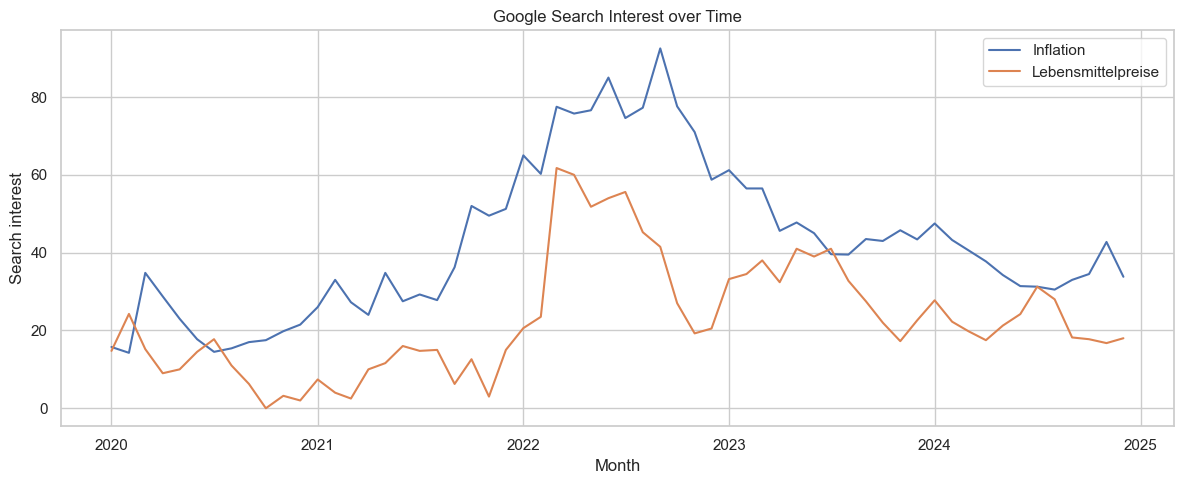

In [43]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=analysis_df, x="month", y="value_inflation", label="Inflation")
sns.lineplot(data=analysis_df, x="month", y="value_food", label="Lebensmittelpreise")

plt.title("Google Search Interest over Time")
plt.xlabel("Month")
plt.ylabel("Search interest")
plt.tight_layout()
plt.show()

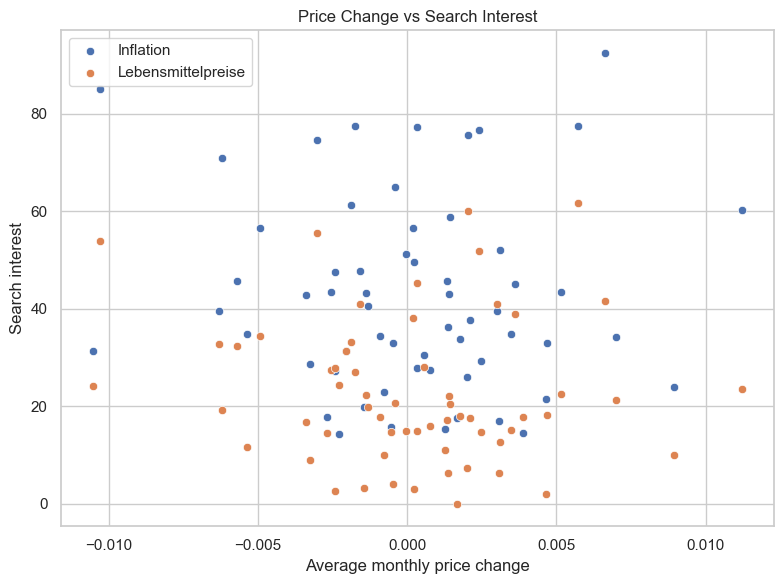

In [44]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=analysis_df,
    x="price_change",
    y="value_inflation",
    label="Inflation"
)

sns.scatterplot(
    data=analysis_df,
    x="price_change",
    y="value_food",
    label="Lebensmittelpreise"
)

plt.title("Price Change vs Search Interest")
plt.xlabel("Average monthly price change")
plt.ylabel("Search interest")
plt.tight_layout()
plt.show()

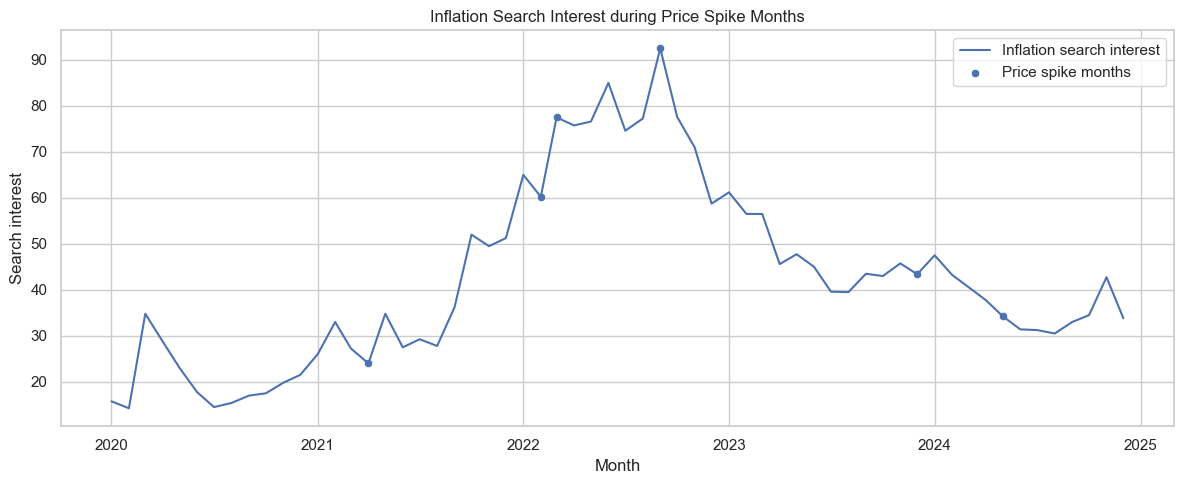

In [45]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=analysis_df,
    x="month",
    y="value_inflation",
    label="Inflation search interest"
)

sns.scatterplot(
    data=analysis_df[analysis_df["price_spike"]],
    x="month",
    y="value_inflation",
    label="Price spike months"
)

plt.title("Inflation Search Interest during Price Spike Months")
plt.xlabel("Month")
plt.ylabel("Search interest")
plt.tight_layout()
plt.show()

In [46]:
summary_table = (
    analysis_df.groupby("price_spike")
    .agg(
        avg_price_change=("price_change", "mean"),
        avg_inflation_search=("value_inflation", "mean"),
        avg_food_search=("value_food", "mean"),
        number_of_months=("month", "count")
    )
    .round(2)
)

summary_table

,avg_price_change,avg_inflation_search,avg_food_search,number_of_months
price_spike,,,,
False,-0.00,41.23,22.04,54
True,0.01,55.32,30.10,6


In [47]:
print("Average inflation search interest in spike months:",
      round(analysis_df.loc[analysis_df["price_spike"], "value_inflation"].mean(), 2))

print("Average inflation search interest in non-spike months:",
      round(analysis_df.loc[~analysis_df["price_spike"], "value_inflation"].mean(), 2))

print("Average food-price search interest in spike months:",
      round(analysis_df.loc[analysis_df["price_spike"], "value_food"].mean(), 2))

print("Average food-price search interest in non-spike months:",
      round(analysis_df.loc[~analysis_df["price_spike"], "value_food"].mean(), 2))

Average inflation search interest in spike months: 55.32
Average inflation search interest in non-spike months: 41.23
Average food-price search interest in spike months: 30.1
Average food-price search interest in non-spike months: 22.04


## Interpretation

The results suggest that months with stronger price spikes are associated with higher Google search interest for both inflation and food prices in Germany.

Average search interest is clearly higher in spike months than in non-spike months. This indicates that sudden price increases may coincide with stronger public attention to economic issues.

However, the analysis is exploratory. It does not prove causality and does not directly measure emotions such as fear or loss of control. Instead, it measures changes in online search behavior.